In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df = sns.load_dataset("penguins")

In [15]:
print("Original Penguin Dataset:")
print(df.head(10))

Original Penguin Dataset:
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   
5  Adelie  Torgersen            39.3           20.6              190.0   
6  Adelie  Torgersen            38.9           17.8              181.0   
7  Adelie  Torgersen            39.2           19.6              195.0   
8  Adelie  Torgersen            34.1           18.1              193.0   
9  Adelie  Torgersen            42.0           20.2              190.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  
5       3

In [16]:
print("\nAre missing values present?")
print(df.isnull().any())


Are missing values present?
species              False
island               False
bill_length_mm        True
bill_depth_mm         True
flipper_length_mm     True
body_mass_g           True
sex                   True
dtype: bool


In [17]:
print("\nTotal missing values in each column:")
print(df.isnull().sum())


Total missing values in each column:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


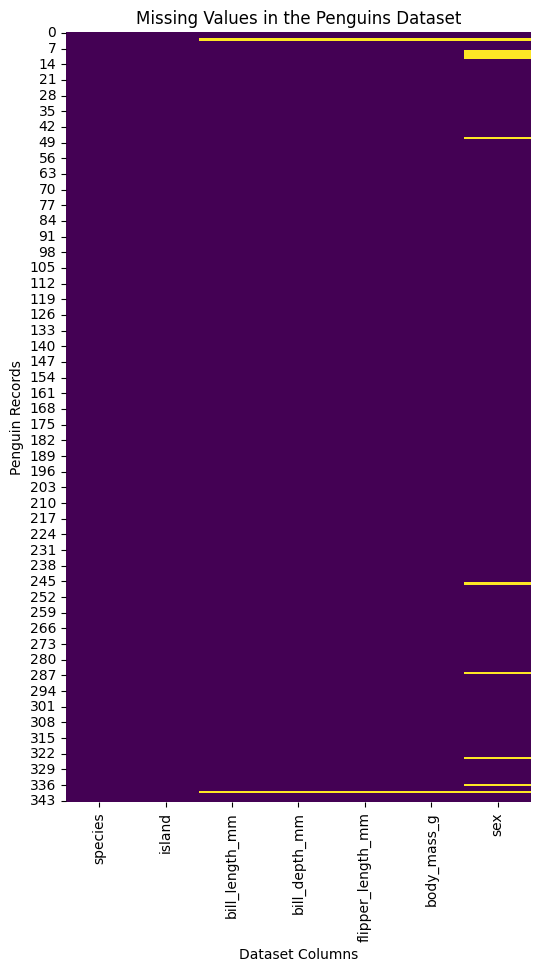

In [18]:
plt.figure(figsize=(6,10))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values in the Penguins Dataset")
plt.xlabel("Dataset Columns")
plt.ylabel("Penguin Records")
plt.show()

In [19]:
df = df.dropna(how="all")

print("\nDataset after removing completly empty rows:")
print(df.head())


Dataset after removing completly empty rows:
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  


In [20]:
categorical_coloumns = [
    "species",
    "island",
    "sex"
]

for coloumn in categorical_coloumns:
    most_common_value = df[coloumn].mode()[0]

    df[coloumn] = df[coloumn].fillna(
        most_common_value
    )

In [21]:
numerical_columns = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]

df[numerical_columns] = (
    df[numerical_columns]
    .interpolate
)

df[numerical_columns] = (
    df[numerical_columns]
    .bfill()
    .ffill()
)

In [22]:
print("\nMissing values after data cleaning:")
print(df.isnull().sum())


Missing values after data cleaning:
species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64


In [23]:
print("\nCleaned Penguin Dataset:")
print(df.head(10))


Cleaned Penguin Dataset:
  species     island                                     bill_length_mm  \
0  Adelie  Torgersen  <bound method NDFrame.interpolate of      bill...   
1  Adelie  Torgersen  <bound method NDFrame.interpolate of      bill...   
2  Adelie  Torgersen  <bound method NDFrame.interpolate of      bill...   
3  Adelie  Torgersen  <bound method NDFrame.interpolate of      bill...   
4  Adelie  Torgersen  <bound method NDFrame.interpolate of      bill...   
5  Adelie  Torgersen  <bound method NDFrame.interpolate of      bill...   
6  Adelie  Torgersen  <bound method NDFrame.interpolate of      bill...   
7  Adelie  Torgersen  <bound method NDFrame.interpolate of      bill...   
8  Adelie  Torgersen  <bound method NDFrame.interpolate of      bill...   
9  Adelie  Torgersen  <bound method NDFrame.interpolate of      bill...   

                                       bill_depth_mm  \
0  <bound method NDFrame.interpolate of      bill...   
1  <bound method NDFrame.interpolate

In [24]:
complete_penguins = df.dropna()

print("\nNumber of completed penguin records:")
print(len(complete_penguins))


Number of completed penguin records:
344
